# Inteligência Computacional Aplicada (TIP7077) - Trabalho 1

**Professor**: Guilherme de Alencar Barreto

<img src="https://loop.frontiersin.org/images/profile/243428/203" alt="Foto do Professor" width="150"/>


**Aluno**: Luis Felipe Carneiro de Souza **Matrícula**: 593034

**Objetivos**:

<a href="https://colab.research.google.com/github/LuisFelipeCSouza/inteligencia-computacional-aplicada/blob/main/trabalho-1/main.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm, trange
from itertools import combinations


In [91]:
from pathlib import Path

BASE_DIR = Path("..").resolve().parent
FIG_DIR = BASE_DIR / "tc-1" / "latex" / "figures"

In [90]:
BASE_DIR = Path('..').parent.resolve().parent
DATA_DIR = BASE_DIR / 'trabalho-1' / 'data' / 'Gauss3.csv'

In [32]:
# data = np.loadtxt(DATA_DIR, skiprows=59, max_rows=11, usecols=(0, 1), unpack=True)
data = np.genfromtxt(DATA_DIR, skip_header=1)
data
X = data[:, [1]]
y = data[:, [0]]

## Modelo Polinomial de ordem k.

In [48]:
class PolynomialRegression:
    def __init__(self, degree, lmbda=0.0):
        self.degree = degree
        self.lmbda = lmbda
        self.coefficients = None

    def fit(self, X, y):

        X_poly = self._polymonil_features(X, self.degree)
        I = np.eye(X.shape[1])
        self.coefficients = np.linalg.solve(X_poly.T @ X_poly + self.lmbda * I, X_poly.T @ y)

    def predict(self, X):
        X_poly = self._polymonil_features(X, self.degree)
        return X_poly @ self.coefficients

    def _polymonil_features(self, X, degree):
        m, n = X.shape
        X_poly = np.ones((m, 1))
        for i in range(n):
            x = X[:, i]
            X_poly = np.c_[X_poly, np.vander(x, degree +1, increasing=True)[:, 1:]]
        return X_poly

## Modelo Linear por partes

In [34]:
class PiecewiseLinearRegression:
    def __init__(self, n_pieces=None, knots=None):
        self.n_pieces = n_pieces
        self.knots = knots
        self.coefficients = None

    def fit(self, X, y):

        X_basis_expanded = self._basis_functions(X)

        self.coefficients = np.linalg.solve(X_basis_expanded.T @ X_basis_expanded, X_basis_expanded.T @ y)

    def predict(self, X):

        X_basis_expanded = self._basis_functions(X)

        return X_basis_expanded @ self.coefficients
    
    def _basis_functions(self, X):
        return np.hstack([
            np.ones(X.shape),
            X,
            np.hstack([
            np.column_stack([
                (X >= kl).astype(float),
                (X >= kl).astype(float) * (X - kl)
            ])
            for kl in self.knots
        ])
        ])


## Modelo Spline Linear

In [35]:
class SplineLinearRegression:
    def __init__(self, n_pieces=None, knots=None):
        self.n_pieces = n_pieces
        self.knots = knots
        self.coefficients = None

    def fit(self, X, y):

        X_basis_expanded = self._basis_functions(X)

        self.coefficients = np.linalg.solve(X_basis_expanded.T @ X_basis_expanded, X_basis_expanded.T @ y)

    def predict(self, X):

        X_basis_expanded = self._basis_functions(X)

        return X_basis_expanded @ self.coefficients
    
    def _basis_functions(self, X):
        return np.hstack(
        [
        np.ones(X.shape),
        X,

        *[np.maximum(X - kl, 0) for kl in self.knots],
        ]
        )


## Modelo Fuzzy do tipo Mamdani

In [36]:
class MamdaniFuzzy:
        
    def __init__(self, centers, spread, singleton_outputs):
        self.centers = np.array(centers)
        self.spread = spread
        self.outputs = np.array(singleton_outputs)
        
    def _gaussian_mf(self, x, c, sigma):
        return np.exp(-((x - c) ** 2) / (2 * sigma ** 2))
    
    def predict(self, X):
        X = np.asarray(X)
        y_pred = []
        
        # Iterando sobre cada amostra de entrada
        for j in range(len(X)):
            # As ativações (mi) das regras são os valores de pertinência da velocidade (Passo 6)
            mi = self._gaussian_mf(float(X[j][0]), self.centers, self.spread)
            
            # A saída predita é a média ponderada das potências de saídas das regras (Eq 12, 13, 14)
            y_pred.append(np.sum(mi * self.outputs) / np.sum(mi))
            
        return np.array(y_pred)
    


## Modelo Fuzzy do tipo Katagi-Sugeno

## R2 Score

In [37]:
def r2_score(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    
    # Valor médio da potência 
    y_mean = np.mean(y_true)
    
    # Erro de predição do modelo Mamdani (Numerador)
    ss_res = np.sum((y_true - y_pred) ** 2)
    
    # Erro do modelo de predição pela média (Denominador)
    ss_tot = np.sum((y_true - y_mean) ** 2)
    
    # Índice R2
    r2 = 1 - (ss_res / ss_tot)
    return r2


## Conjunto de dados

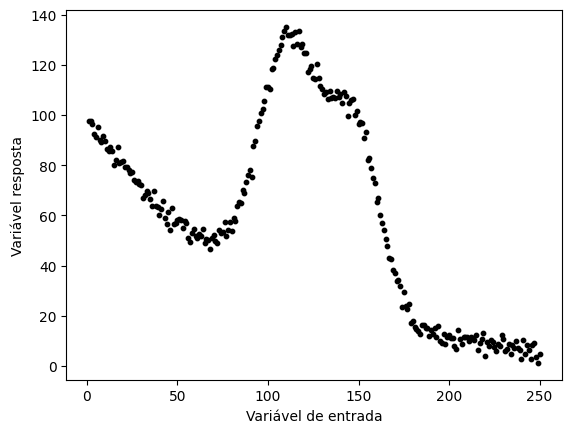

In [38]:
fig, ax = plt.subplots()

ax.scatter(X, y, c='k', s=10)

ax.set_facecolor('none')
fig.patch.set_alpha(0.0)
# ax.set_axis_off()

ax.set_xlabel("Variável de entrada")
ax.set_ylabel("Variável resposta")

plt.show()

# fig.savefig('data.pdf', transparent=True, bbox_inches='tight')

## Analises

### Modelo polinomial de ordem K

In [55]:
# r2_scores = []
# y_preds = []
# coeffs = []

ks = range(1, 30+1)

results = {f'k={i}': {} for i in ks}

for i in ks:
    
    model1 = PolynomialRegression(i)
    model1.fit(X, y)
    y_pred = model1.predict(X)

    results[f'k={i}']['coeffs'] = model1.coefficients
    results[f'k={i}']['y_pred'] = y_pred
    results[f'k={i}']['r2'] = r2_score(y_true=y, y_pred=y_pred)
    results[f'k={i}']['k'] = i

    # r2_scores.append(r2_score(y_true=y, y_pred=y_pred))

In [ ]:
results

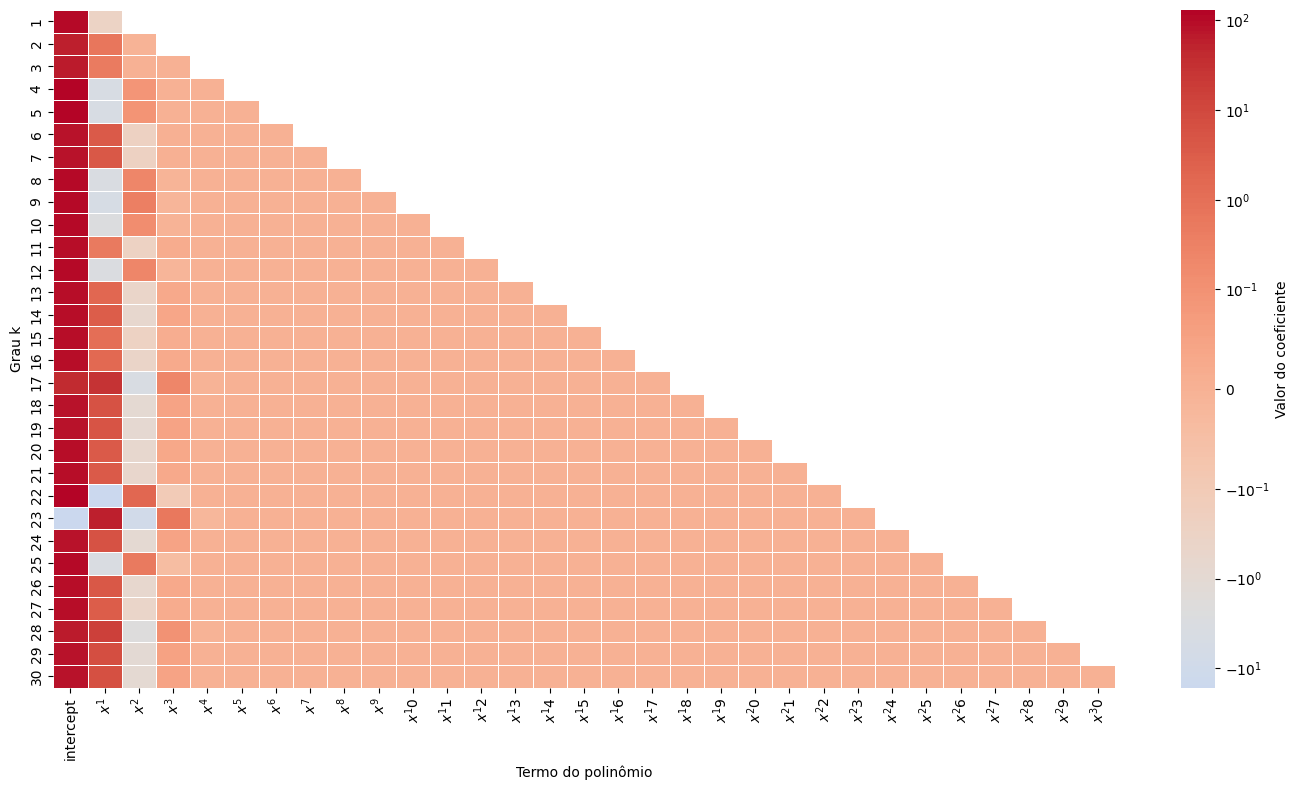

In [74]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import SymLogNorm
import seaborn as sns
import pandas as pd

# Extrai os coeficientes para cada k
coeffs_dict = {}
max_len = 0
for k in ks:
    coeffs = results[f'k={k}']['coeffs']
    coeffs_dict[k] = coeffs
    max_len = max(max_len, len(coeffs))

# Cria matriz num_k x max_len com NaN
ks_list = sorted(coeffs_dict.keys())
data = np.full((len(ks_list), max_len), np.nan)
for i, k in enumerate(ks_list):
    c = coeffs_dict[k]
    data[i, :len(c)] = c.ravel()   # <--- correção aqui

# Rótulos das colunas (ajuste conforme número de features)
col_labels = ['intercept'] + [f'$x^{p}$' for p in range(1, max_len)]

df = pd.DataFrame(data, index=ks_list, columns=col_labels)

# Heatmap
plt.figure(figsize=(14, 8))
norm = SymLogNorm(linthresh=0.1, linscale=1.0, vmin=df.min().min(), vmax=df.max().max())

sns.heatmap(df, annot=False, fmt='.2f', cmap='coolwarm', norm=norm, center=0,
            linewidths=.5, cbar_kws={'label': 'Valor do coeficiente'})

# sns.heatmap(df, annot=False, fmt='.2f', cmap='coolwarm', center=0,
#             linewidths=.5, cbar_kws={'label': 'Valor do coeficiente'})
# plt.title('Heatmap dos coeficientes da regressão polinomial (k = 4 a 30)')
plt.xlabel('Termo do polinômio')
plt.ylabel('Grau k')
plt.tight_layout()
plt.show()

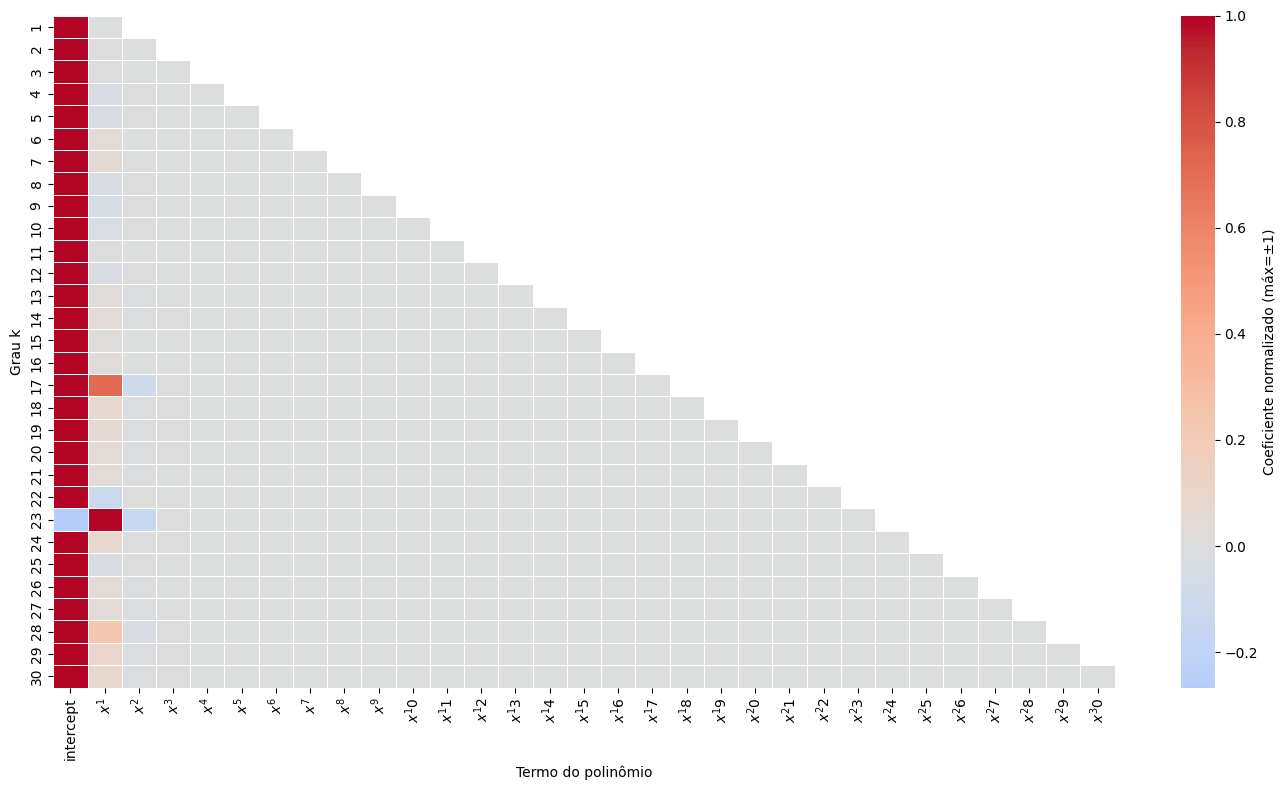

In [68]:
max_abs = df.abs().max(axis=1)
df_norm = df.div(max_abs, axis=0)
# A coluna que antes era dominante agora terá valor ±1, e as demais ficarão entre -1 e 1.

plt.figure(figsize=(14, 8))
sns.heatmap(df_norm, annot=False, cmap='coolwarm', center=0,
            linewidths=.5, cbar_kws={'label': 'Coeficiente normalizado (máx=±1)'})
plt.xlabel('Termo do polinômio')
plt.ylabel('Grau k')
plt.tight_layout()
plt.show()

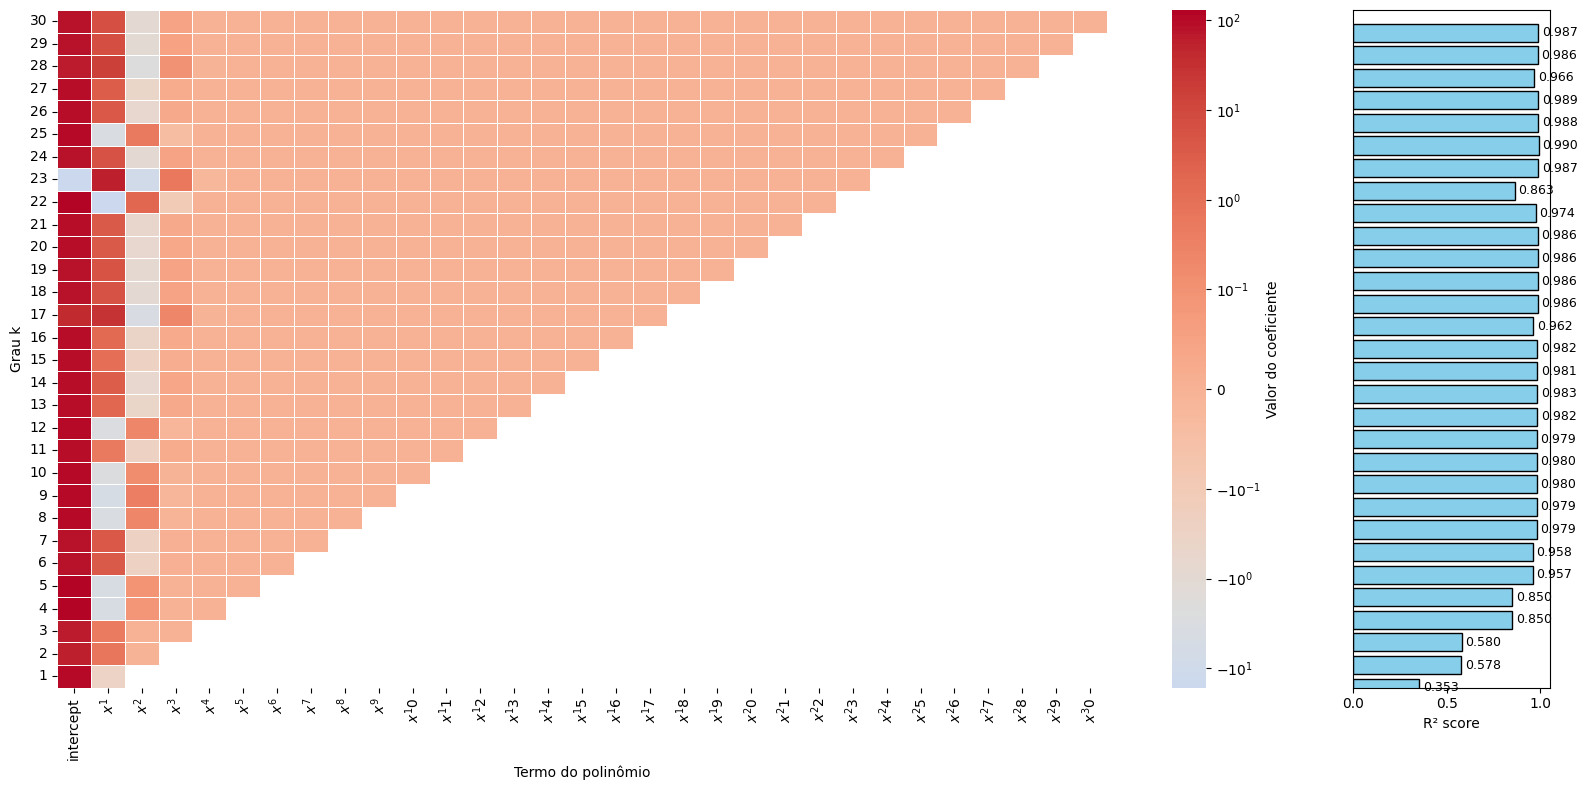

In [75]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import SymLogNorm
import seaborn as sns
import pandas as pd

# 1. Extrai os coeficientes e o R²
coeffs_dict = {}
r2_dict = {}
max_len = 0
for k in ks:
    coeffs = results[f'k={k}']['coeffs']
    coeffs_dict[k] = coeffs
    r2_dict[k] = results[f'k={k}']['r2']
    max_len = max(max_len, len(coeffs))

ks_list = sorted(coeffs_dict.keys())
data = np.full((len(ks_list), max_len), np.nan)
for i, k in enumerate(ks_list):
    c = coeffs_dict[k]
    data[i, :len(c)] = c.ravel()

col_labels = ['intercept'] + [f'$x^{p}$' for p in range(1, max_len)]
df = pd.DataFrame(data, index=ks_list, columns=col_labels)

# 2. Prepara a figura com dois subplots
fig, (ax_heat, ax_r2) = plt.subplots(
    1, 2, figsize=(16, 8),
    gridspec_kw={'width_ratios': [4, 0.6]},  # heatmap maior, barra de R² mais estreita
    sharey=True                               # alinha as linhas verticalmente
)

# 3. Heatmap dos coeficientes (mantendo sua normalização)
norm = SymLogNorm(linthresh=0.1, linscale=1.0, vmin=df.min().min(), vmax=df.max().max())
sns.heatmap(df, annot=False, cmap='coolwarm', norm=norm, center=0,
            linewidths=.5, cbar_kws={'label': 'Valor do coeficiente'}, ax=ax_heat)
ax_heat.set_xlabel('Termo do polinômio')
ax_heat.set_ylabel('Grau k')
# Rotula as linhas com o valor de k (opcional)
ax_heat.set_yticklabels(ks_list, rotation=0)

# 4. Gráfico de barras do R²
r2_vals = [r2_dict[k] for k in ks_list]
ax_r2.barh(np.arange(len(ks_list)), r2_vals, height=0.8,
           color='skyblue', edgecolor='black')
ax_r2.set_xlim(0, 1.05)                # R² normalmente entre 0 e 1
ax_r2.set_xlabel('R² score')
ax_r2.set_ylabel('')                   # remove rótulo duplicado
ax_r2.tick_params(axis='y', length=0)  # remove os ticks do eixo y

# Adiciona o valor do R² ao lado de cada barra
for i, val in enumerate(r2_vals):
    ax_r2.text(val + 0.02, i, f'{val:.3f}', va='center', fontsize=9)

# Inverte o eixo y para que k=4 fique no topo (como no heatmap)
ax_r2.invert_yaxis()

plt.tight_layout()
plt.show()

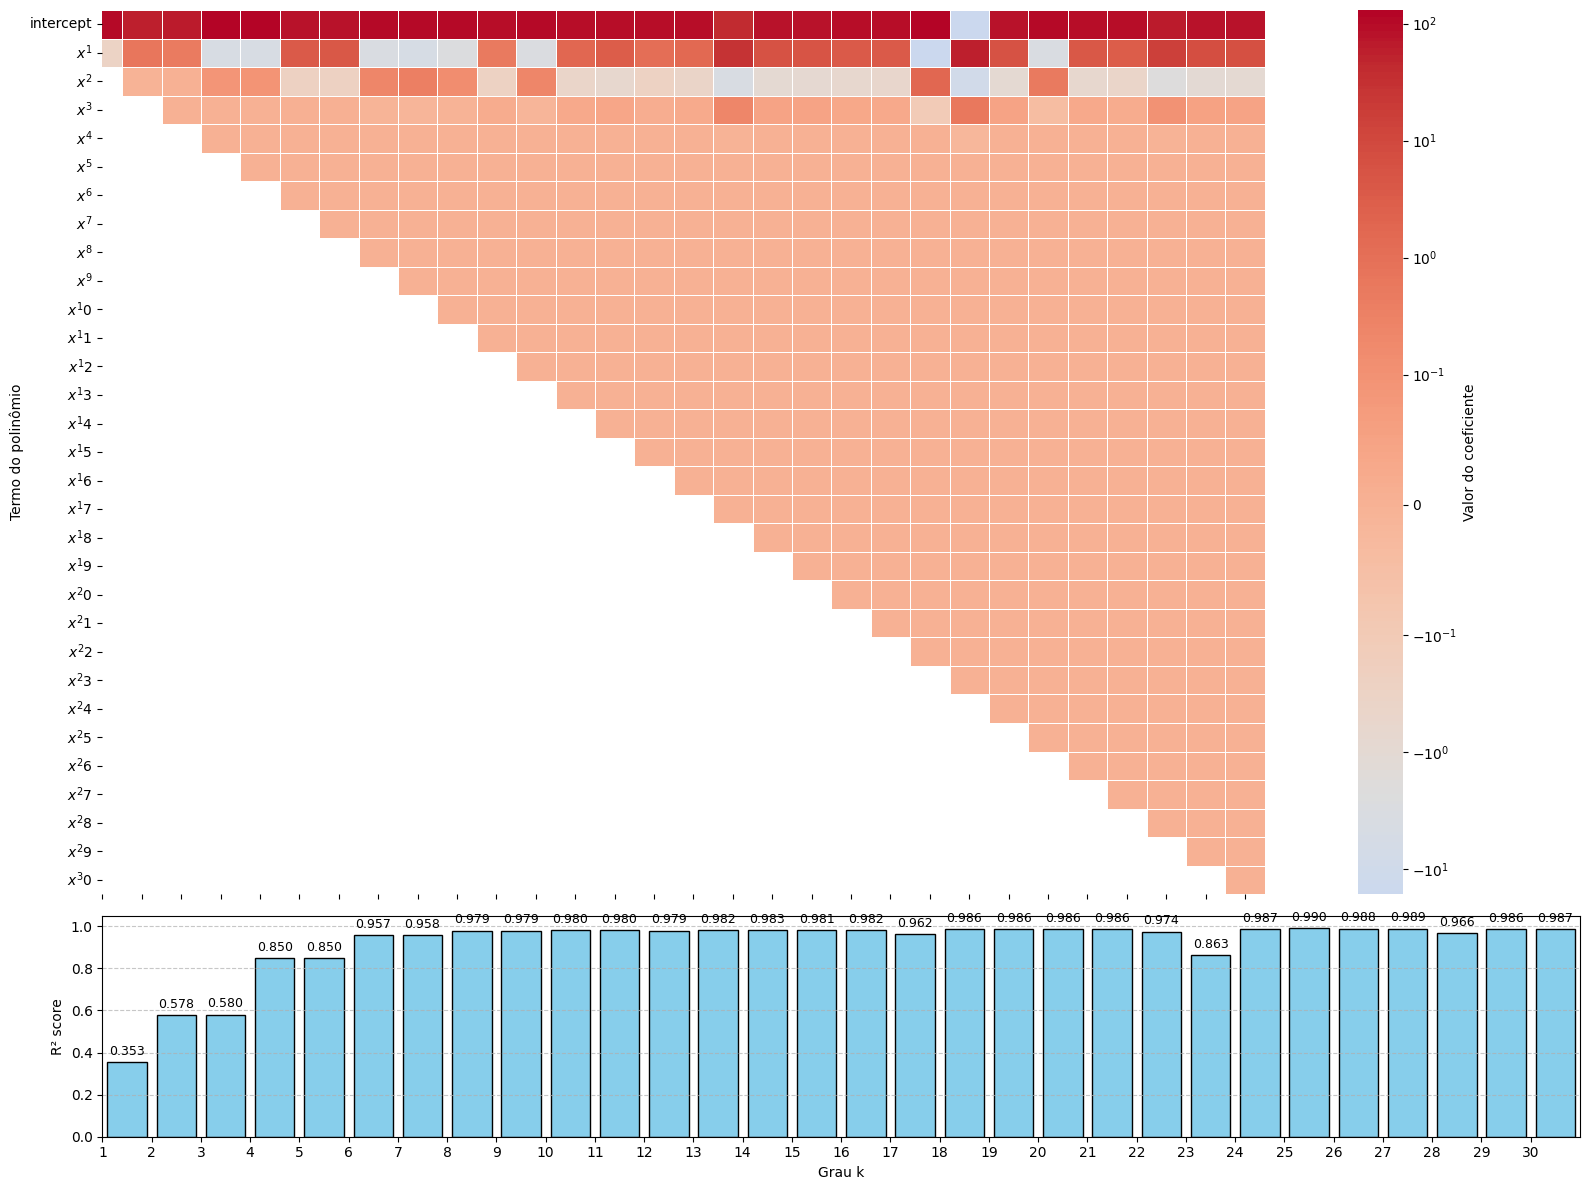

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import SymLogNorm
import seaborn as sns
import pandas as pd

# 1. Extrai os coeficientes e o R²
coeffs_dict = {}
r2_dict = {}
max_len = 0
for k in ks:
    coeffs = results[f'k={k}']['coeffs']
    coeffs_dict[k] = coeffs
    r2_dict[k] = results[f'k={k}']['r2']
    max_len = max(max_len, len(coeffs))

ks_list = sorted(coeffs_dict.keys())
# Matriz original: linhas = k, colunas = termos (preenchida com NaN)
data = np.full((len(ks_list), max_len), np.nan)
for i, k in enumerate(ks_list):
    c = coeffs_dict[k]
    data[i, :len(c)] = c.ravel()

col_labels = ['intercept'] + [f'$x^{p}$' for p in range(1, max_len)]

# 2. Transpõe a matriz: agora linhas = termos, colunas = k
# Isso realiza a rotação de 90° anti‑horário do heatmap
data_T = data.T
df_rot = pd.DataFrame(data_T, index=col_labels, columns=ks_list)

# 3. Prepara a figura com dois subplots empilhados verticalmente
fig, (ax_heat, ax_r2) = plt.subplots(
    2, 1, figsize=(16, 12),
    gridspec_kw={'height_ratios': [4, 1]},   # heatmap mais alto
    sharex=True                               # alinha os valores de k no eixo x
)

# 4. Heatmap rotacionado: eixo y = termos, eixo x = k
norm = SymLogNorm(linthresh=0.1, linscale=1.0,
                  vmin=df_rot.min().min(), vmax=df_rot.max().max())
sns.heatmap(df_rot, annot=False, cmap='coolwarm', norm=norm, center=0,
            linewidths=.5, cbar_kws={'label': 'Valor do coeficiente'}, ax=ax_heat)
ax_heat.set_ylabel('Termo do polinômio')
ax_heat.set_xlabel('')                      # já compartilhado com o gráfico de baixo
ax_heat.tick_params(axis='x', labelbottom=False)  # esconde os rótulos de k no topo

# 5. Gráfico de barras verticais do R² abaixo do heatmap
x_pos = np.arange(len(ks_list))
r2_vals = [r2_dict[k] for k in ks_list]
ax_r2.bar(ks_list, r2_vals, width=0.8, color='skyblue', edgecolor='black')
ax_r2.set_ylim(0, 1.05)
ax_r2.set_ylabel('R² score')
ax_r2.set_xlabel('Grau k')
ax_r2.grid(axis='y', linestyle='--', alpha=0.7)

# Adiciona o valor do R² sobre cada barra
for x, val in zip(ks_list, r2_vals):
    ax_r2.text(x, val + 0.02, f'{val:.3f}', ha='center', va='bottom', fontsize=9)

# Ajusta os limites do eixo x para cobrir todos os k
ax_r2.set_xlim(min(ks_list) - 0.5, max(ks_list) + 0.5)

plt.tight_layout()
plt.show()

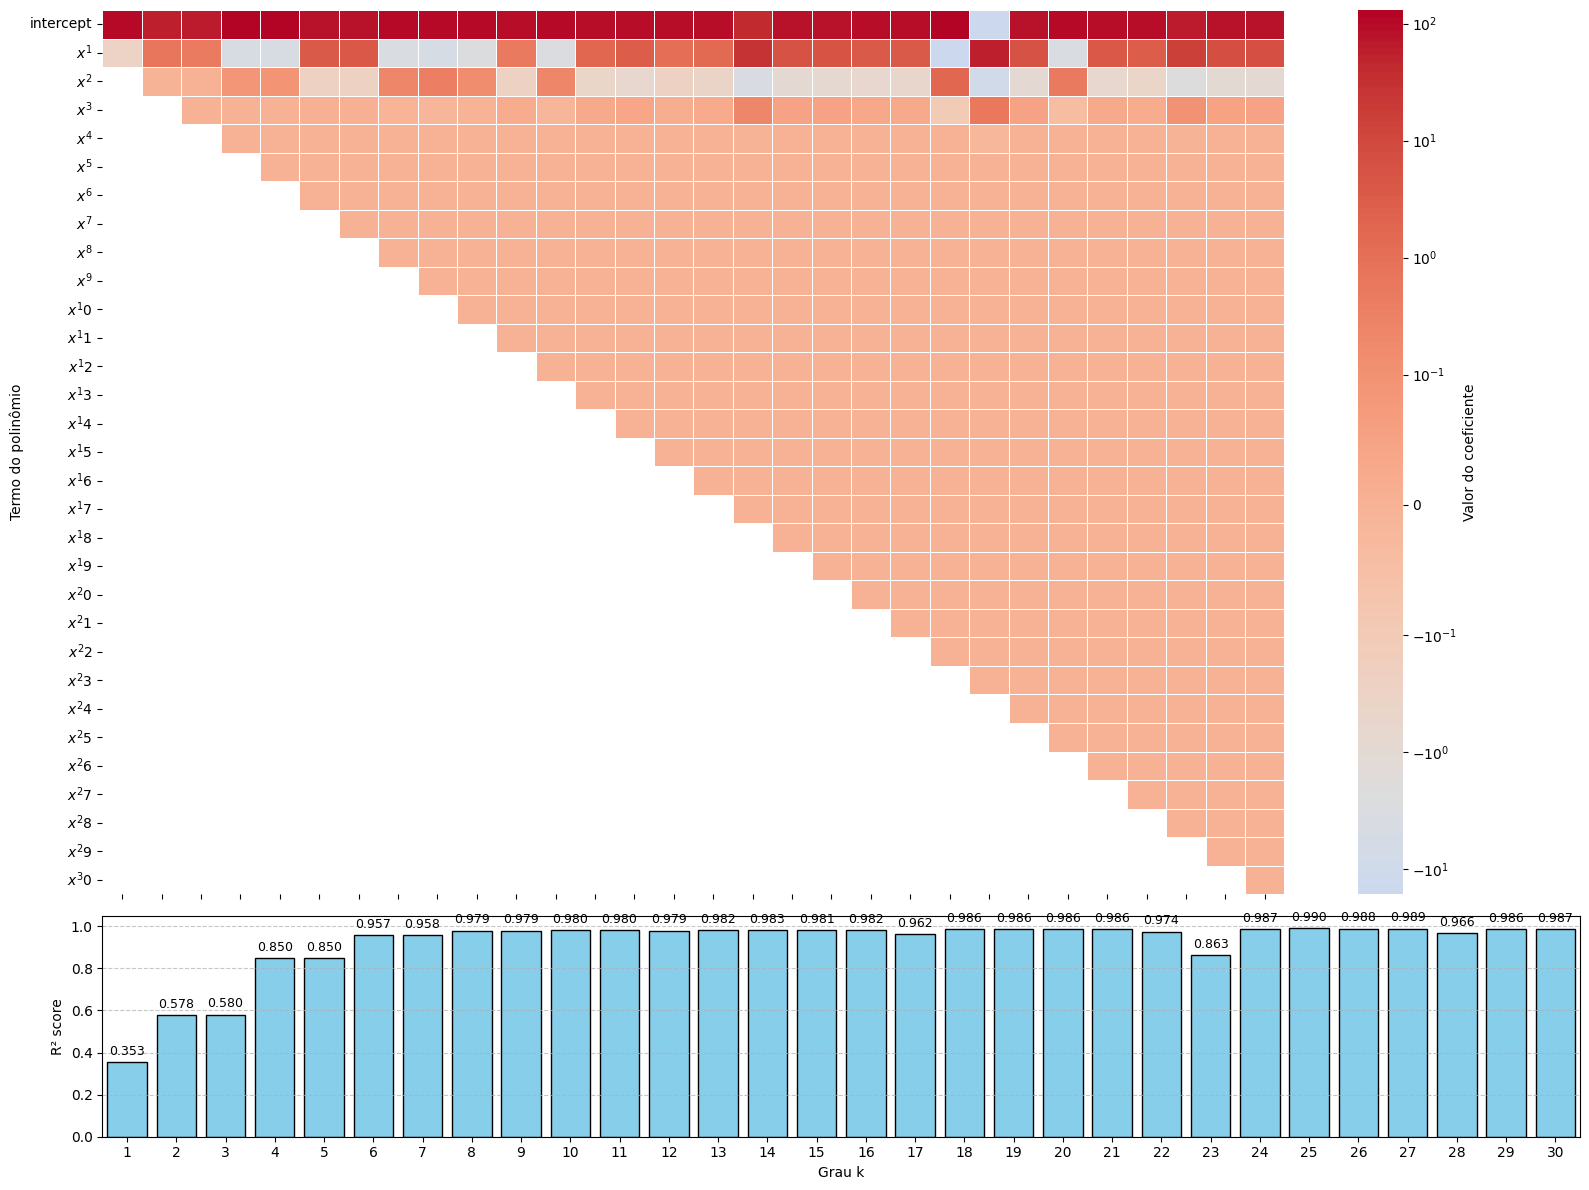

In [77]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import SymLogNorm
import seaborn as sns
import pandas as pd

# 1. Extrai os coeficientes e o R²
coeffs_dict = {}
r2_dict = {}
max_len = 0
for k in ks:
    coeffs = results[f'k={k}']['coeffs']
    coeffs_dict[k] = coeffs
    r2_dict[k] = results[f'k={k}']['r2']
    max_len = max(max_len, len(coeffs))

ks_list = sorted(coeffs_dict.keys())
data = np.full((len(ks_list), max_len), np.nan)
for i, k in enumerate(ks_list):
    c = coeffs_dict[k]
    data[i, :len(c)] = c.ravel()

col_labels = ['intercept'] + [f'$x^{p}$' for p in range(1, max_len)]

# 2. Transpõe a matriz
data_T = data.T
df_rot = pd.DataFrame(data_T, index=col_labels, columns=ks_list)

# 3. Prepara a figura: dois subplots empilhados verticalmente
fig, (ax_heat, ax_r2) = plt.subplots(
    2, 1, figsize=(16, 12),
    gridspec_kw={'height_ratios': [4, 1]},
    sharex=False  # não compartilhar, para podermos ajustar ticks com precisão
)

# 4. Heatmap rotacionado
norm = SymLogNorm(linthresh=0.1, linscale=1.0,
                  vmin=df_rot.min().min(), vmax=df_rot.max().max())
sns.heatmap(df_rot, annot=False, cmap='coolwarm', norm=norm, center=0,
            linewidths=.5, cbar_kws={'label': 'Valor do coeficiente'}, ax=ax_heat)
ax_heat.set_ylabel('Termo do polinômio')
ax_heat.set_xlabel('')
ax_heat.tick_params(axis='x', labelbottom=False)

# 5. Gráfico de barras do R² alinhado
x_pos = np.arange(len(ks_list))  # índices correspondentes às colunas do heatmap
r2_vals = [r2_dict[k] for k in ks_list]
ax_r2.bar(x_pos, r2_vals, width=0.8, color='skyblue', edgecolor='black')
ax_r2.set_xticks(x_pos)
ax_r2.set_xticklabels(ks_list)
ax_r2.set_xlim(-0.5, len(ks_list) - 0.5)  # alinhado com os limites padrão do heatmap
ax_r2.set_ylim(0, 1.05)
ax_r2.set_ylabel('R² score')
ax_r2.set_xlabel('Grau k')
ax_r2.grid(axis='y', linestyle='--', alpha=0.7)

# Adiciona valor do R²
for x, val in zip(x_pos, r2_vals):
    ax_r2.text(x, val + 0.02, f'{val:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

C:\Users\luisx\AppData\Local\Temp\ipykernel_26344\3312768066.py:81: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


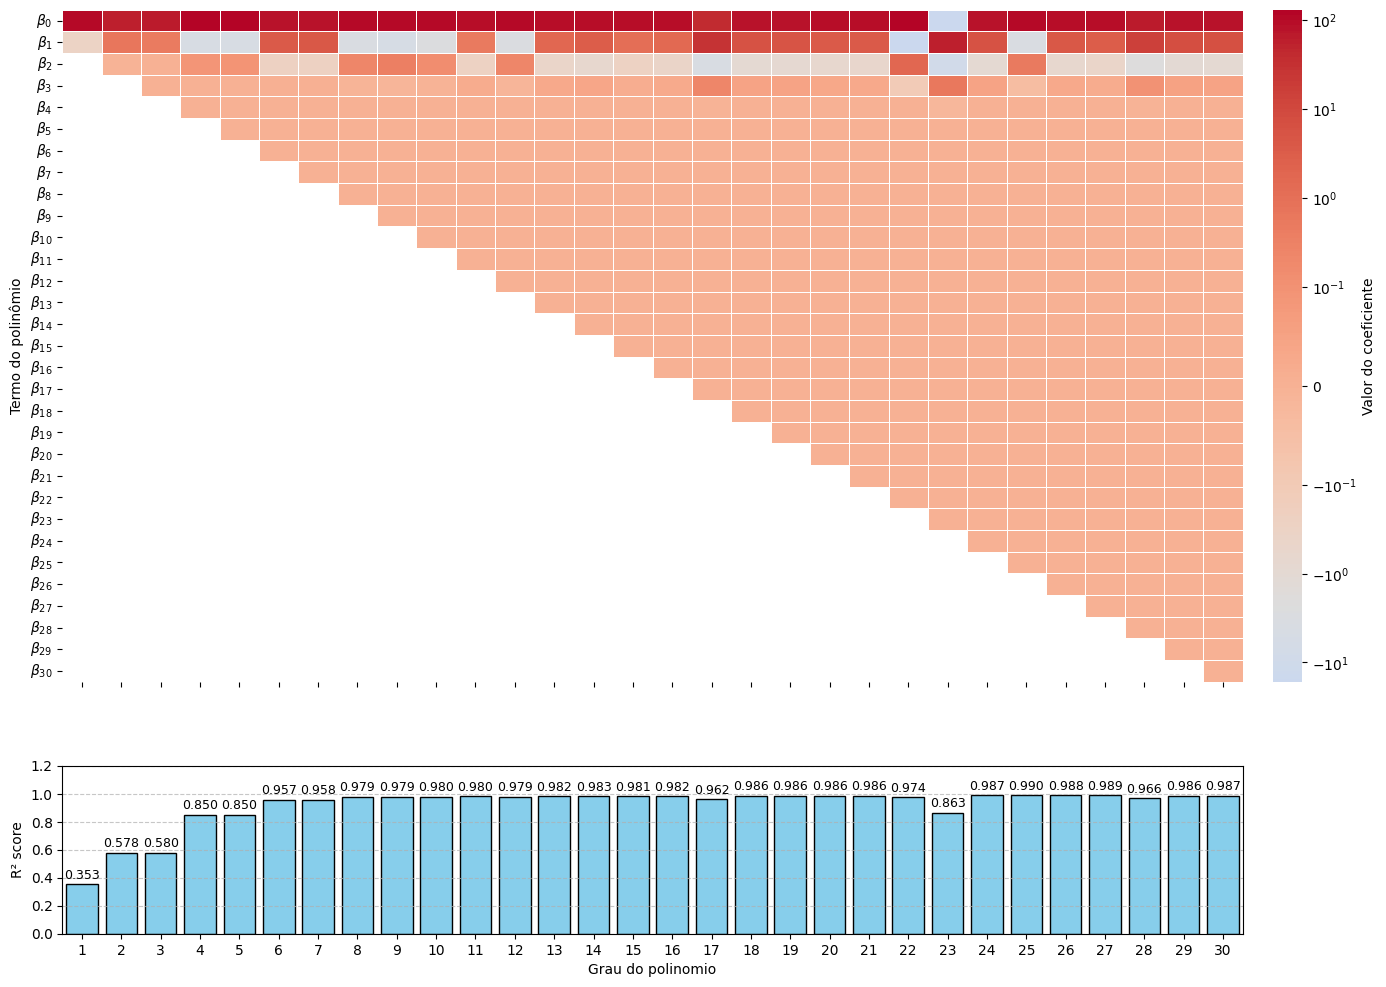

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import SymLogNorm
import seaborn as sns
import pandas as pd

# (Assumindo que ks e results já estão definidos no seu ambiente)

# 1. Extrai os coeficientes e o R²
coeffs_dict = {}
r2_dict = {}
max_len = 0
for k in ks:
    coeffs = results[f'k={k}']['coeffs']
    coeffs_dict[k] = coeffs
    r2_dict[k] = results[f'k={k}']['r2']
    max_len = max(max_len, len(coeffs))

ks_list = sorted(coeffs_dict.keys())
data = np.full((len(ks_list), max_len), np.nan)
for i, k in enumerate(ks_list):
    c = coeffs_dict[k]
    data[i, :len(c)] = c.ravel()

col_labels = [r'$\beta_0$'] + [fr'$\beta_{{{p}}}$' for p in range(1, max_len)]

# 2. Transpõe a matriz
data_T = data.T
df_rot = pd.DataFrame(data_T, index=col_labels, columns=ks_list)

# ---------------------------------------------------------
# 3. Prepara a figura: GridSpec com 2 linhas e 2 colunas
# Coluna 0: Heatmap (linha 0) e Bar chart (linha 1)
# Coluna 1: Colorbar (linha 0) e Vazio (linha 1)
# ---------------------------------------------------------
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(
    2, 2, 
    height_ratios=[4, 1],   # Proporção de altura entre Heatmap e Barras
    width_ratios=[40, 1],   # Proporção de largura (Gráficos vs Colorbar)
    wspace=0.05             # Espaço horizontal entre o heatmap e a colorbar
)

ax_heat = fig.add_subplot(gs[0, 0])
cbar_ax = fig.add_subplot(gs[0, 1]) # Eixo exclusivo para a barra de cores
ax_r2   = fig.add_subplot(gs[1, 0]) # Fica na mesma coluna do ax_heat, garantindo a mesma largura

# 4. Heatmap rotacionado
norm = SymLogNorm(linthresh=0.1, linscale=1.0,
                  vmin=df_rot.min().min(), vmax=df_rot.max().max())

# Passamos o cbar_ax explicitamente para o seaborn não encolher o ax_heat
sns.heatmap(df_rot, annot=False, cmap='coolwarm', norm=norm, center=0,
            linewidths=.5, cbar_ax=cbar_ax, cbar_kws={'label': 'Valor do coeficiente'}, ax=ax_heat)

ax_heat.set_ylabel('Termo do polinômio')
ax_heat.set_xlabel('')
ax_heat.tick_params(axis='x', labelbottom=False)

# 5. Gráfico de barras do R² alinhado
x_pos = np.arange(len(ks_list))  
r2_vals = [r2_dict[k] for k in ks_list]
ax_r2.bar(x_pos, r2_vals, width=0.8, color='skyblue', edgecolor='black')
ax_r2.set_xticks(x_pos)
ax_r2.set_xticklabels(ks_list)

# A sua lógica de limites (-0.5 a N-0.5) já é perfeita para alinhar 
# com a forma como o seaborn renderiza as colunas do heatmap
ax_r2.set_xlim(-0.5, len(ks_list) - 0.5) 
ax_r2.set_ylim(0, 1.2)
ax_r2.set_ylabel('R² score')
ax_r2.set_xlabel('Grau do polinomio')
ax_r2.grid(axis='y', linestyle='--', alpha=0.7)

# Adiciona valor do R²
for x, val in zip(x_pos, r2_vals):
    ax_r2.text(x, val + 0.02, f'{val:.3f}', ha='center', va='bottom', fontsize=9)

# tight_layout não é totalmente compatível com gridspec customizado com cbar_ax, 
# mas se precisar de mais espaço, você pode usar plt.subplots_adjust() ou fig.tight_layout()
fig.tight_layout()

plt.savefig(FIG_DIR / "poly_result.pdf", bbox_inches='tight')

plt.show()

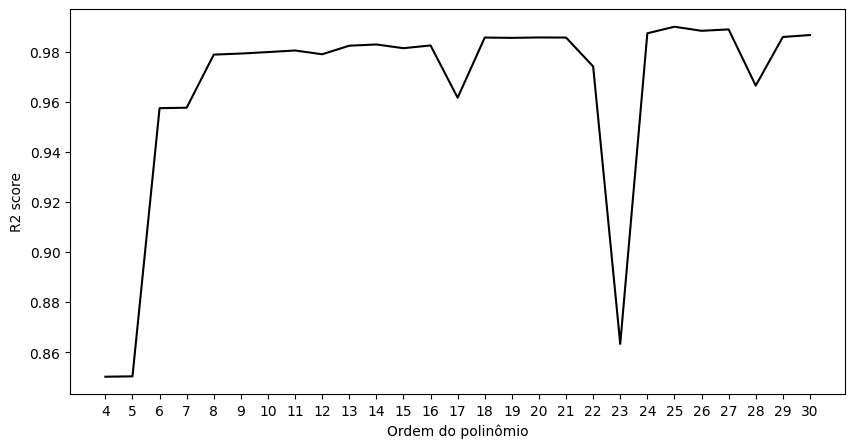

In [27]:
fig, ax = plt.subplots(figsize=(10, 5))

# ax.plot(range(4, 4+len(r2_scores)), r2_scores, drawstyle='steps-pre', c='k')
ax.plot(range(4, 4+len(r2_scores)), r2_scores, c='k')
ax.set_xlabel("Ordem do polinômio")
ax.set_ylabel("R2 score")
ax.set_xticks(ks)

plt.show()

In [62]:
for i in ks:
    print(f'modelo de ordem {i}')
    print(results[f'k={i}']['coeffs'])

modelo de ordem 1
[[101.9246909 ]
 [ -0.32982325]]
modelo de ordem 2
[[ 5.88982621e+01]
 [ 6.94615530e-01]
 [-4.08142941e-03]]
modelo de ordem 3
[[ 6.37778552e+01]
 [ 4.63630371e-01]
 [-1.78536640e-03]
 [-6.09844092e-06]]
modelo de ordem 4
[[ 1.28799043e+02]
 [-4.62595441e+00]
 [ 8.90377809e-02]
 [-5.68217303e-04]
 [ 1.11975869e-06]]
modelo de ordem 5
[[ 1.30518624e+02]
 [-4.82589161e+00]
 [ 9.45692652e-02]
 [-6.26807747e-04]
 [ 1.38210084e-06]
 [-4.18075142e-10]]
modelo de ordem 6
[[ 7.91134794e+01]
 [ 3.44498785e+00]
 [-2.31007907e-01]
 [ 4.53555116e-03]
 [-3.70955258e-05]
 [ 1.34374163e-07]
 [-1.79006956e-10]]
modelo de ordem 7
[[ 7.67749284e+01]
 [ 3.93997404e+00]
 [-2.57188674e-01]
 [ 5.11073439e-03]
 [-4.33742685e-05]
 [ 1.70331952e-07]
 [-2.82400680e-10]
 [ 1.17693483e-13]]
modelo de ordem 8
[[ 1.04552503e+02]
 [-3.50546091e+00]
 [ 2.50543845e-01]
 [-9.57295729e-03]
 [ 1.74837026e-04]
 [-1.63275282e-06]
 [ 8.08614496e-09]
 [-2.02830269e-11]
 [ 2.03194437e-14]]
modelo de ordem 9


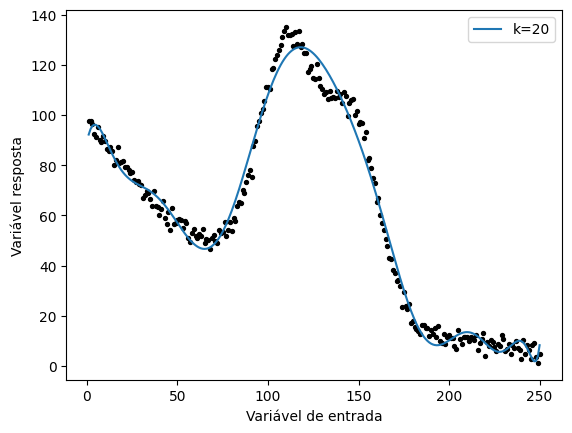

In [14]:
fig, ax = plt.subplots()

ax.scatter(X, y, c='k', s=8)

for i in [20]:
    ax.plot(X, results[f'k={i}']['y_pred'], label=f'k={i}')

ax.set_xlabel("Variável de entrada")
ax.set_ylabel("Variável resposta")

ax.legend()
plt.show()


### Modelo Linear por partes

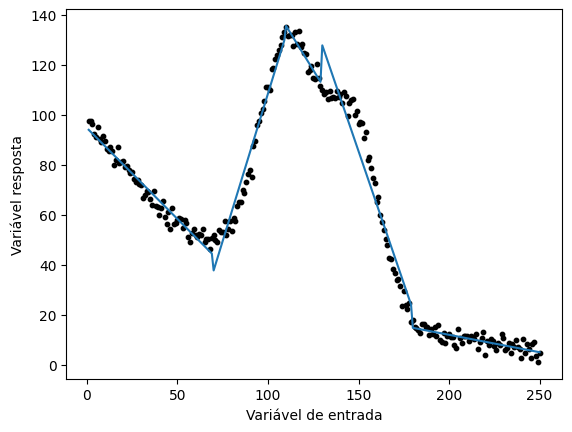

In [15]:
pwreg = PiecewiseLinearRegression(knots=[70, 110, 130, 180])
pwreg.fit(X, y)
y_pred = pwreg.predict(X)

fig, ax = plt.subplots()

ax.scatter(X, y, c='k', s=10)
ax.plot(X, y_pred)

ax.set_facecolor('none')
fig.patch.set_alpha(0.0)
# ax.set_axis_off()

ax.set_xlabel("Variável de entrada")
ax.set_ylabel("Variável resposta")

plt.show()


### Mamdani

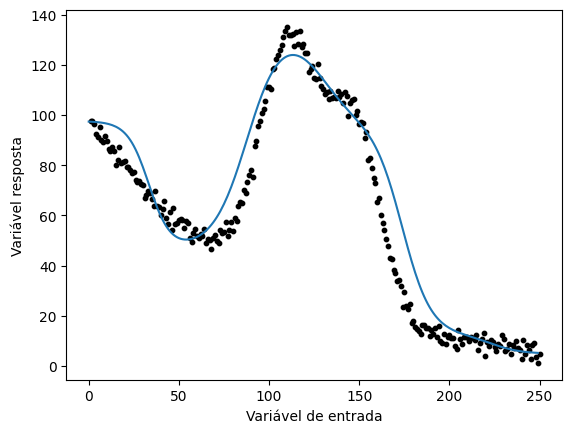

In [16]:

centros = [1, 68, 110, 150, 200, 250]
potencias_saida = [97.58, 46.44, 135.12, 96.44, 12.42, 4.87]
raio = 1.35              
raio = 20

# Instanciando o modelo
modelo_fuzzy = MamdaniFuzzy(centers=centros, spread=raio, singleton_outputs=potencias_saida)

y_pred = modelo_fuzzy.predict(X)
y_pred

# plt.plot(y)
# plt.plot(y_pred)
# plt.scatter(centros, potencias_saida)

fig, ax = plt.subplots()

ax.scatter(X, y, c='k', s=10)

ax.plot(y_pred)

ax.set_facecolor('none')
fig.patch.set_alpha(0.0)
# ax.set_axis_off()

ax.set_xlabel("Variável de entrada")
ax.set_ylabel("Variável resposta")

plt.show()


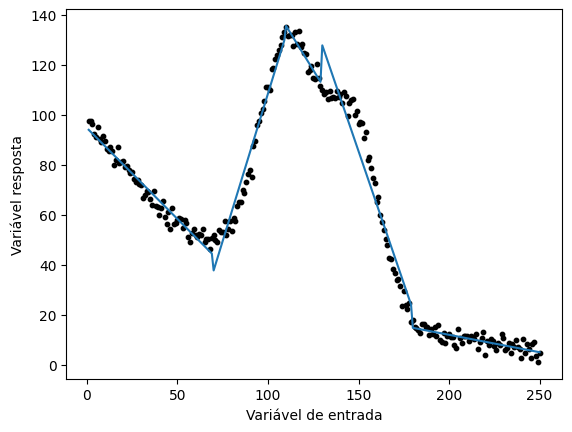

In [17]:
pwreg = PiecewiseLinearRegression(knots=[70, 110, 130, 180])
pwreg.fit(X, y)
y_pred = pwreg.predict(X)

fig, ax = plt.subplots()

ax.scatter(X, y, c='k', s=10)
ax.plot(X, y_pred)

ax.set_facecolor('none')
fig.patch.set_alpha(0.0)
# ax.set_axis_off()

ax.set_xlabel("Variável de entrada")
ax.set_ylabel("Variável resposta")

plt.show()
